# Ejercicio de clase: Predicción del precio de vivienda con Decision Tree Regressor

**Dataset**: California Housing Prices — https://www.kaggle.com/datasets/camnugent/california-housing-prices

En el ejemplo de clase (`decision_tree_example.ipynb`) usamos un **Decision Tree Classifier** para predecir
si un paciente sobrevivía o no a una sepsis. Esa era una tarea de **clasificación**: la variable que
queríamos predecir (`hospital_outcome`) solo podía tomar un número limitado de valores (0 o 1, "vive" o
"muere").

En este ejercicio vamos a resolver un problema distinto: **regresión**. Vamos a predecir el **precio
mediano de una vivienda** (`median_house_value`) en un bloque censal de California, a partir de
características como la ubicación, la cantidad de habitaciones o el ingreso medio de sus habitantes.

> **Diferencia clave**: en clasificación el modelo predice una *categoría* (una clase). En regresión el
> modelo predice un *número real* (puede tomar, en principio, cualquier valor dentro de un rango continuo).
> Esto tiene consecuencias importantes: no podemos usar métricas como *precision*, *recall* o *F1*, porque
> esas métricas comparan clases exactas. En su lugar usaremos métricas que midan **qué tan lejos** está la
> predicción del valor real, como el **MAE (Mean Absolute Error)**, que veremos más adelante.

Para este ejercicio usarán `DecisionTreeRegressor` en lugar de `DecisionTreeClassifier`.

### Antes de empezar

1. Descarguen el dataset desde Kaggle: https://www.kaggle.com/datasets/camnugent/california-housing-prices
2. El archivo se llama `housing.csv`. Colóquenlo dentro de la carpeta `raw/` de este proyecto
   (la misma carpeta `decision_tree/raw/` donde está el dataset de sepsis).
3. Sigan cada sección en orden. Cada sección tiene:
   - Una breve explicación de qué vamos a hacer y por qué.
   - Un **reto**: ustedes deben escribir el código (no está resuelto).
   - **Preguntas de análisis**: respóndanlas en una celda de markdown justo debajo de su código.


### Importar librerías

Igual que en el ejemplo de clase, empezamos importando las librerías que vamos a necesitar. Noten dos
diferencias frente al ejemplo de clasificación:

- Usamos `DecisionTreeRegressor` en lugar de `DecisionTreeClassifier`.
- Usamos `mean_absolute_error` en lugar de `precision_score`, `recall_score`, `f1_score`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error


## Paso 1 — Cargar los datos

**Reto**: Carguen el archivo `housing.csv` (carpeta `raw/`) en un DataFrame de pandas llamado `df`, tal
como hicimos en el ejemplo de clase con `pd.read_csv(...)`. Luego muestren las primeras filas del
DataFrame para confirmar que se cargó correctamente.


In [2]:
# Cargar el dataset en un DataFrame llamado df
df = pd.read_csv("raw/housing.csv")

In [3]:
# Mostrar las primeras filas del DataFrame
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Preguntas de análisis**

1. ¿Cuántas filas y cuántas columnas tiene el dataset? (pista: `df.shape`)

El dataset tiene **20.640 filas** y **10 columnas**.


2. ¿Qué representa cada fila del dataset? ¿Es una vivienda individual o algo distinto?

Cada fila representa un **bloque censal** de California, no una vivienda individual. Los valores de las habitaciones, la población, los hogares y el precio son datos agregados de todas las viviendas de ese bloque.


3. Observando los nombres de las columnas, ¿cuál creen que es la variable que vamos a predecir (el
   *target*)?

La variable que vamos a predecir es `median_house_value`, porque representa el precio mediano de las viviendas del bloque censal.

## Paso 2 — Identificación inicial de los datos

Antes de tocar cualquier dato, siempre debemos entender con qué estamos trabajando: cuántas columnas hay,
qué tipo de dato tiene cada una, si hay valores nulos, y cuál es el rango de valores de cada variable.

**Reto**: Usando lo que ya conocen de pandas, respondan (con código) estas tres preguntas:
1. ¿Qué tipo de dato (`dtype`) tiene cada columna? ¿Hay alguna columna categórica (texto)?
2. ¿Cuáles son las estadísticas básicas (media, desviación estándar, mínimo, máximo, etc.) de las
   columnas numéricas?
3. ¿Hay valores nulos (faltantes) en el dataset? ¿En qué columna(s)?

Pistas de los métodos que necesitan (ya los usamos, en otra forma, en el ejemplo de clase): `.info()`,
`.describe()`, `.isnull()`.


In [4]:
# Tipos de dato de cada columna y resumen general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Cantidad de valores nulos por columna
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

**Preguntas de análisis**

1. ¿Cuál es la única columna categórica (de texto) del dataset? ¿Qué valores puede tomar?

La única columna categórica es `ocean_proximity`. Sus valores son `NEAR BAY`, `<1H OCEAN`, `INLAND`, `NEAR OCEAN` e `ISLAND`.


2. ¿Qué columna tiene valores nulos? ¿Cuántas filas están afectadas, aproximadamente qué porcentaje del
   total representa?

Los valores nulos aparecen en `total_bedrooms`: hay **207 filas**, aproximadamente el **1,00 %** del dataset.


3. Miren el `min` y el `max` de `median_house_value`. ¿Les parece un rango razonable para el precio de una
   vivienda? ¿Notan algo raro en el valor máximo? (pista: busquen cuántas filas tienen exactamente ese
   valor máximo).

`median_house_value` va desde **14.999** hasta **500.001 dólares**. El máximo resulta sospechoso porque está limitado artificialmente: hay **965 registros** con exactamente ese valor, así que probablemente el dataset agrupó todos los precios superiores en 500.001.


4. Comparen el rango de `median_income` con el de `total_rooms`. ¿Están en escalas muy distintas? ¿Creen
   que eso sería un problema para un Decision Tree? (piensen en cómo el árbol elige los cortes: ¿necesita
   que las variables estén en la misma escala, como sí lo necesitan otros modelos?)

 Las escalas son muy diferentes: `median_income` va aproximadamente de 0,5 a 15, mientras `total_rooms` llega a 39.320. Esto no es un problema importante para un árbol de decisión, porque el árbol busca puntos de corte dentro de cada variable y no necesita que todas estén en la misma escala.

## Paso 3 — Procesamiento de datos

Por ahora, para mantener el ejercicio simple, vamos a trabajar **solo con variables numéricas**. Más
adelante en el curso aprenderemos técnicas para incorporar variables categóricas (como *one-hot encoding*),
pero hoy las vamos a descartar.

**Reto**:
1. Eliminen del DataFrame la(s) columna(s) categórica(s) que identificaron en el paso anterior.
2. Decidan qué hacer con los valores nulos que encontraron (por ejemplo, eliminar esas filas) y
   apliquen esa decisión. Un Decision Tree Regressor de scikit-learn no puede entrenarse si quedan
   valores `NaN` en los datos.
3. Confirmen, con código, que ya no quedan columnas categóricas ni valores nulos.


In [7]:
# Eliminar la columna categórica ocean_proximity
df_num = df.drop(columns=["ocean_proximity"]).copy()

In [8]:
# Eliminar las filas que contienen valores nulos
df_num = df_num.dropna().copy()

In [9]:
# Confirmar que todas las columnas son numéricas y que no quedan nulos
print(df_num.dtypes)
print("Valores nulos totales:", df_num.isnull().sum().sum())

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object
Valores nulos totales: 0


**Preguntas de análisis**


1. ¿Qué información de las viviendas estamos perdiendo al eliminar la columna categórica? ¿Creen que esa
   información podría ser útil para predecir el precio? ¿Por qué?

Al eliminar `ocean_proximity` perdemos información sobre la cercanía al océano. Esa información probablemente sí ayuda a predecir el precio, porque las zonas costeras suelen tener precios distintos de las zonas del interior. La eliminamos solo para mantener el ejercicio sencillo; en un proyecto real usaríamos *one-hot encoding*.


2. Si eliminaron filas con nulos, ¿cuántas filas quedaron en total? ¿Qué porcentaje del dataset original
   se perdió?

Después de eliminar los nulos quedaron **20.433 filas**. Se perdieron **207 filas**, aproximadamente el **1,00 %** del dataset original.


3. ¿Qué otra estrategia (distinta a eliminar las filas) existe para tratar valores nulos? ¿Por qué hoy
   optamos por la más simple?

Otra opción sería rellenar los valores faltantes, por ejemplo, con la mediana de `total_bedrooms` o con un método de imputación más avanzado. Hoy elegimos eliminar las filas porque es la alternativa más fácil de entender y la pérdida de datos es pequeña.

## Paso 4 — Definir variables predictoras (X) y variable objetivo (y), y dividir los datos

Igual que en el ejemplo de clase, necesitamos separar:
- **X**: las columnas que el modelo usará para predecir (todas menos el precio).
- **y**: la columna que queremos predecir (`median_house_value`).

Y luego dividir ambas en un conjunto de **entrenamiento** y uno de **prueba**, usando
`train_test_split`, tal como hicimos con los datos de sepsis.

**Reto**:
1. Construyan `X` (todas las columnas numéricas excepto `median_house_value`) y `y`
   (`median_house_value`).
2. Usen `train_test_split` para crear `X_train`, `X_test`, `y_train`, `y_test`. Usen un `test_size` de
   0.2 y `random_state=0` para que los resultados sean reproducibles.


In [10]:
# Construir X (predictoras) y y (target)
X = df_num.drop(columns=["median_house_value"])
y = df_num["median_house_value"]

In [13]:
# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16346, 8)
X_test: (4087, 8)


**Preguntas de análisis**

1. ¿Cuántas filas quedaron en `X_train` y cuántas en `X_test`?

`X_train` tiene **16.346 filas** y `X_test` tiene **4.087 filas**.


2. ¿Por qué es importante evaluar el modelo en datos que **no** usó para entrenar (`X_test`, `y_test`)?
   ¿Qué pasaría si evaluáramos únicamente sobre `X_train`?

Es importante evaluar con datos que el modelo no ha visto, porque así comprobamos si aprendió patrones generales o simplemente memorizó los ejemplos de entrenamiento. Si evaluáramos solo sobre `X_train`, el resultado parecería demasiado bueno y podríamos pasar por alto el sobreajuste.


3. En el ejemplo de clase balanceamos las clases con SMOTE antes de dividir los datos. Aquí no lo hicimos.
   ¿Por qué SMOTE (que genera ejemplos sintéticos de una *clase* minoritaria) no tiene sentido en un
   problema de regresión, donde no hay clases sino un valor continuo?

SMOTE no encaja aquí porque no estamos intentando equilibrar clases. En regresión el objetivo es un número continuo, no una categoría minoritaria; por eso no tiene sentido crear ejemplos sintéticos de una clase.

## Paso 5 — Entrenar el Decision Tree Regressor

**Reto**: Entrenen un `DecisionTreeRegressor` (con `random_state=0`) usando `X_train` y `y_train`, de la
misma forma en que entrenaron el `DecisionTreeClassifier` en el ejemplo de clase.


In [15]:
# Crear y entrenar el modelo
reg = DecisionTreeRegressor(random_state=0)
reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

**Preguntas de análisis**

1. En clasificación, cada hoja del árbol predice una clase (por ejemplo, "vive" o "muere"). En regresión,
   ¿qué creen que predice cada hoja del árbol? (pista: piensen en los valores de `y` que caen en esa
   hoja durante el entrenamiento).

En regresión, cada hoja predice un valor numérico. Con el criterio predeterminado, ese valor es normalmente la **media de los precios** de las observaciones de entrenamiento que llegan a esa hoja.


2. ¿Qué criterio usa por defecto `DecisionTreeRegressor` para decidir dónde hacer cada corte, en lugar del
   *gini* o *entropy* que se usan en clasificación? (revisen la documentación del parámetro `criterion`).
El criterio predeterminado es `squared_error`, que busca reducir el error cuadrático medio, equivalente a reducir la variabilidad de los precios dentro de cada grupo. No usa `gini` ni `entropy`, porque esos criterios son propios de clasificación.

## Paso 6 — Evaluar el modelo con MAE

### ¿Qué es el MAE (Mean Absolute Error)?

El **MAE** es el promedio de la diferencia absoluta entre el valor real y el valor predicho:

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

A diferencia de precision/recall/F1 (que solo tienen sentido cuando comparamos clases), el MAE funciona
sobre valores numéricos continuos y nos dice, **en promedio, cuánto se equivoca el modelo, en las mismas
unidades que la variable objetivo**. En nuestro caso, como `median_house_value` está en dólares, un
MAE de, por ejemplo, 40000 significa que en promedio el modelo se equivoca en $40,000 dólares al predecir
el precio de una vivienda.

Un MAE más bajo es mejor. Pero un mismo valor de MAE puede ser "bueno" o "malo" dependiendo de la escala
de la variable que estamos prediciendo — por eso siempre hay que compararlo contra algo (por ejemplo,
el precio promedio de las viviendas).

**Reto**:
1. Usen el modelo entrenado para predecir sobre `X_train` y calculen el MAE comparando esas predicciones
   con `y_train`.
2. Hagan lo mismo sobre `X_test` con `y_test`.
3. Comparen ambos valores.


In [16]:
# Predicciones y MAE sobre el set de entrenamiento
y_train_pred = reg.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE (train):", mae_train)

MAE (train): 0.0


In [17]:
# Predicciones y MAE sobre el set de prueba
y_test_pred = reg.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE (test):", mae_test)

MAE (test): 43557.103743577194


**Preguntas de análisis**
1. ¿El MAE de entrenamiento es mayor, menor o similar al MAE de prueba? ¿Qué les dice eso sobre qué tan
   bien "memorizó" el árbol los datos de entrenamiento?

El MAE de entrenamiento es **0**, mientras que el de prueba es aproximadamente **43.557 dólares**. La diferencia es muy grande: el árbol completamente desarrollado memorizó prácticamente todos los ejemplos de entrenamiento.


2. Calculen el precio promedio (`.mean()`) de `median_house_value` en todo el dataset. Comparando ese
   promedio con el MAE de prueba, ¿el error del modelo les parece grande o pequeño en proporción al precio
   típico de una vivienda?

El precio promedio del dataset es aproximadamente **206.856 dólares**. Un error de unos 43.557 dólares representa cerca del **21 %** del precio promedio, así que no es un error pequeño para una predicción individual.


3. En el ejemplo de clase, un árbol sin restricciones (`fully grown`) mostraba señales de sobreajuste
   (*overfitting*) al compararlo con un árbol más simple (`max_depth=3`). Según los MAE de train y test
   que obtuvieron, ¿creen que este árbol también está sobreajustado? ¿Por qué?
   
Sí, hay señales claras de sobreajuste. El árbol funciona perfecto sobre los datos que ya vio, pero su error aumenta bastante cuando predice sobre datos nuevos. Eso indica que aprendió detalles específicos del conjunto de entrenamiento en vez de generalizar bien.

## Reto adicional (opcional) — ¿Se puede mejorar el árbol?

En el ejemplo de clase, limitar la profundidad del árbol (`max_depth=3`) cambió el comportamiento del
modelo. Prueben lo mismo aquí:

1. Entrenen un segundo `DecisionTreeRegressor`, esta vez fijando `max_depth` (prueben con distintos
   valores, por ejemplo 3, 5, 10).
2. Calculen el MAE de train y de test para cada valor de `max_depth`.
3. Grafiquen (opcional) el MAE de train y de test contra `max_depth`, como una curva.

**Preguntas de análisis**

1. ¿Qué le pasa al MAE de entrenamiento a medida que aumentan `max_depth`? ¿Y al de prueba?

El MAE de entrenamiento baja cuando aumentamos `max_depth`: pasa de aproximadamente **60.960** con profundidad 3 a **0** cuando dejamos el árbol sin límite. El MAE de prueba también mejora al principio, pero no indefinidamente.


2. ¿Existe un valor de `max_depth` donde el MAE de prueba deja de mejorar (o empeora)? ¿Qué relación tiene
   eso con el concepto de *overfitting* que vimos en el ejemplo de clase?

En estas pruebas, el mejor resultado de prueba aparece con `max_depth=10`, con un MAE de aproximadamente **40.590 dólares**. Con `max_depth=15` el error deja de mejorar y con el árbol sin límite sube a **43.557 dólares**. Ese patrón es típico del sobreajuste: un árbol demasiado profundo sigue mejorando en entrenamiento, pero empieza a empeorar con datos nuevos.


3. Miren `reg.feature_importances_` del árbol entrenado. ¿Cuáles son las 2 o 3 variables más importantes
   para predecir el precio de la vivienda? ¿Tiene sentido con lo que ustedes esperarían intuitivamente?

Las tres variables más importantes fueron `median_income` (0,514), `longitude` (0,171) y `latitude` (0,160). Tiene sentido: el ingreso medio suele estar muy relacionado con el precio, y la ubicación también captura diferencias importantes entre las zonas de California.

    max_depth     mae_train      mae_test
0           3  60959.983597  61404.840790
1           5  52174.938951  54349.267723
2          10  31093.303914  40589.700618
3          15  11506.290417  41161.033513
4  sin limite      0.000000  43557.103744


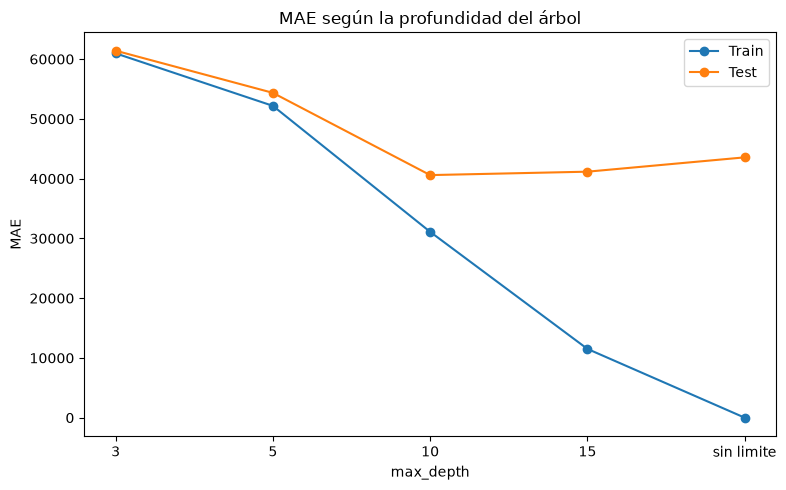

Variables más importantes:
median_income    0.513873
longitude        0.171168
latitude         0.159964
dtype: float64


In [18]:
# Comparar distintas profundidades y visualizar su MAE
max_depths = [3, 5, 10, 15, None]
results = []

for max_depth in max_depths:
    depth_reg = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
    depth_reg.fit(X_train, y_train)
    results.append({
        "max_depth": max_depth if max_depth is not None else "sin limite",
        "mae_train": mean_absolute_error(y_train, depth_reg.predict(X_train)),
        "mae_test": mean_absolute_error(y_test, depth_reg.predict(X_test)),
    })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df["max_depth"].astype(str), results_df["mae_train"], marker="o", label="Train")
plt.plot(results_df["max_depth"].astype(str), results_df["mae_test"], marker="o", label="Test")
plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("MAE según la profundidad del árbol")
plt.legend()
plt.tight_layout()
plt.show()

feature_importance = pd.Series(reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Variables más importantes:")
print(feature_importance.head(3))